# Robomimic Perturbation and Recovery (Refactored)
This script demonstrates using the `a2l-pr` package to apply synthetic perturbations
to a robomimic HDF5 trajectory, replacing the old monolithic notebook.

In [1]:
import os
import sys
import h5py

# Ensure the a2l-pr package is in the path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

from a2l_pr.adapters.robomimic import RobomimicAdapter
from a2l_pr.perturbations.generator import PerturbationGenerator, PerturbationType
from a2l_pr.recovery.generator import RecoveryCodeGenerator, recovery_to_json
from a2l_pr.utils.visualization import visualize_trajectory_comparison
from a2l_pr.config.config import ConfigManager

## Utility function to load a single robomimic trajectory from HDF5

In [2]:
def load_robomimic_trajectory(hdf5_path, demo_key="demo_0"):
    """Loads a single trajectory dictionary from a standard robomimic HDF5 file."""
    if not os.path.exists(hdf5_path):
        print(f"HDF5 file not found: {hdf5_path}")
        return None
        
    f = h5py.File(hdf5_path, 'r')
    if "data" not in f or demo_key not in f["data"]:
        print(f"Invalid HDF5 structure or missing {demo_key}")
        f.close()
        return None
        
    demo_grp = f["data"][demo_key]
    obs_grp = demo_grp["obs"]
    
    # Reconstruct the dictionary
    trajectory = {
        'actions': demo_grp["actions"][:],
        'observations': {}
    }
    
    for key in obs_grp.keys():
        trajectory['observations'][key] = obs_grp[key][:]
        
    f.close()
    return trajectory

## Configuration and Loading

In [3]:
# Load configuration
config_path = os.path.abspath(os.path.join(os.getcwd(), "..", "perturbation_config.yaml"))
config_mgr = ConfigManager.from_yaml(config_path)

# Path to Robomimic HDF5 (Update this to point to a valid dataset)
# Using a dummy path for demonstration. The user should point this to their actual dataset.
robomimic_hdf5_path = os.path.abspath(os.path.join(
    os.getcwd(), "..", "..", "robomimic", "robomimic", "datasets", "square", "ph", "low_dim_v15.hdf5"
))

# We'll use a mocked trajectory if the file doesn't exist just to show the API structure.
import numpy as np
raw_trajectory = load_robomimic_trajectory(robomimic_hdf5_path)

if raw_trajectory is None:
    print("Loading a synthetic dummy trajectory for demonstration purposes.")
    traj_len = 100
    t = np.linspace(0, 1, traj_len)
    raw_trajectory = {
        'observations': {
            'robot0_eef_pos': np.column_stack((t, t, t)),
            'robot0_gripper_qpos': np.concatenate((np.zeros((50, 1)), np.ones((50, 1)))) # close at step 50
        },
        'actions': np.random.randn(traj_len, 7)
    }

# Apply Adapter
adapter = RobomimicAdapter()
trajectory = adapter.load(raw_trajectory)

# Inject dataset defaults from config
dataset_defaults = config_mgr.get_dataset_defaults(trajectory['metadata']['dataset_type'])
trajectory['metadata'].update(dataset_defaults)
trajectory['metadata'].update(config_mgr.get_perturbation_config())

print(f"Loaded Robomimic trajectory with {len(trajectory['actions'])} steps.")

Loaded Robomimic trajectory with 127 steps.


## Apply Perturbation

Applying Underreach Idle Perturbation...
Success! Perturbation applied: LATERAL_DRIFT
Failure Mode: Calibration drift or lateral disturbance that misses alignment.


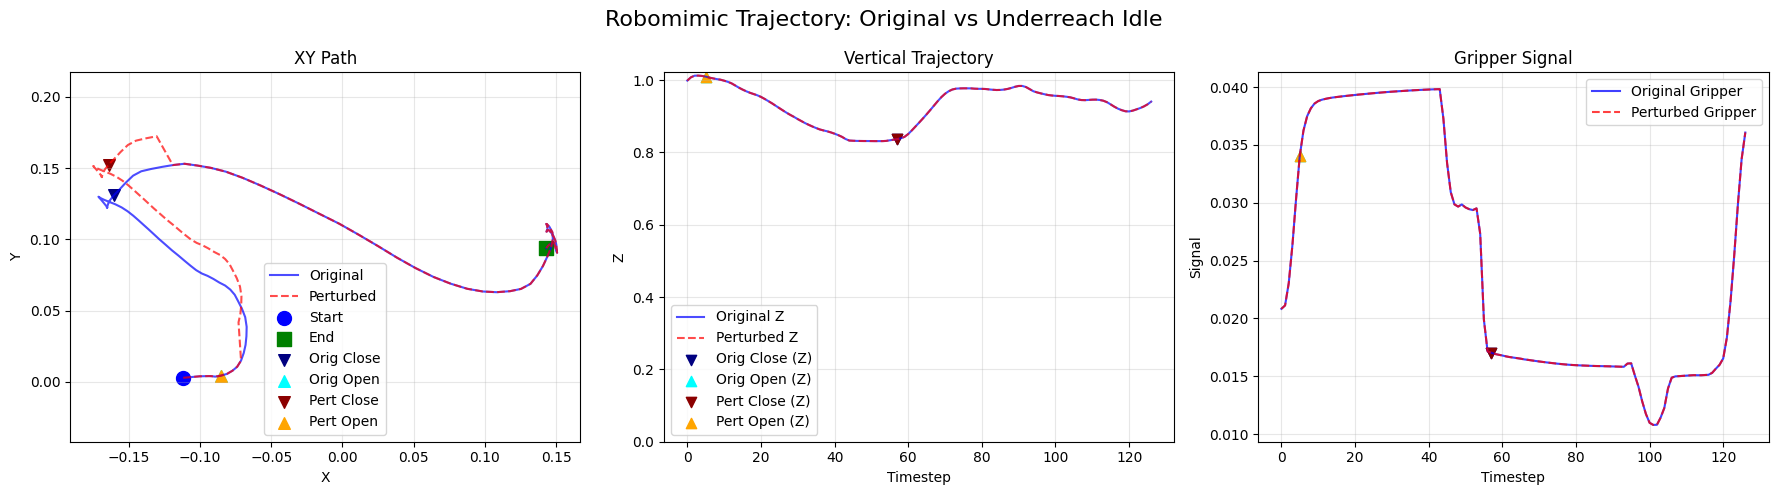

In [4]:
# Initialize generator
generator = PerturbationGenerator()

# Apply an Underreach Idle perturbation
print("Applying Underreach Idle Perturbation...")
result = generator.apply_perturbation(
    trajectory, 
    # PerturbationType.UNDERREACH_IDLE, 
    PerturbationType.LATERAL_DRIFT, 
    severity=0.5,
    seed=42
)

if result is not None:
    print(f"Success! Perturbation applied: {result.perturbation_type.name}")
    print(f"Failure Mode: {result.theoretical_failure_mode}")
    
    # Visualize the comparison
    visualize_trajectory_comparison(
        trajectory, 
        result.perturbed_trajectory, 
        title="Robomimic Trajectory: Original vs Underreach Idle"
    )
else:
    print("Perturbation not applicable for this trajectory.")

## Generate Recovery FSM

In [5]:
if result is not None:
    print("\nGenerating Recovery FSM DSL...")
    recovery_code = RecoveryCodeGenerator.generate_recovery_code(result)
    
    # Pretty print the JSON
    print(recovery_to_json(recovery_code))


Generating Recovery FSM DSL...
{
  "dsl_version": "deterministic_recovery_fsm_v1",
  "execution_model": "sequential_fsm",
  "severity_hint": "moderate",
  "parameters": {
    "perturbation_type": "lateral_drift",
    "lateral_offset_xy": [
      -0.00366729361487686,
      0.021515875194682947
    ],
    "xy_tolerance_m": 0.045,
    "speed_scale": 0.375
  },
  "robot_interface_contract": {
    "requires_live_ee_pose": true,
    "requires_gripper_state_if_used": false,
    "requires_metric_evaluator": true,
    "history_context_required": false
  },
  "program": [
    {
      "id": "S1",
      "call": "align_lateral_error(reference=\"target_or_reference_path\", frame=\"task_plane_xy\", xy_tolerance_m=0.0450, speed_scale=0.38)",
      "termination": {
        "logic": "ANY",
        "predicates": [
          {
            "lhs": "alignment_error_m",
            "cmp": "<=",
            "rhs": 0.045
          }
        ],
        "max_steps": 20
      },
      "next_on_success": "S2",
  

## 10. Simulator Video Playback

In [6]:
import os
import h5py
import imageio
import numpy as np
from pathlib import Path
from IPython.display import HTML, display
from base64 import b64encode

try:
    import robomimic.utils.obs_utils as ObsUtils
    import robomimic.utils.env_utils as EnvUtils
    import robomimic.utils.file_utils as FileUtils
except ImportError:
    print("robomimic is not installed. Video playback may fail.")

def render_trajectory_to_video(traj_dict, dataset_path, ep_name, output_path):
    if not os.path.exists(dataset_path):
        print(f"Dataset {dataset_path} not found.")
        return False

    # Initialize headless env
    dummy_spec = dict(obs=dict(low_dim=["robot0_eef_pos"], rgb=[]))
    ObsUtils.initialize_obs_utils_with_obs_specs(obs_modality_specs=dummy_spec)
    env_meta = FileUtils.get_env_metadata_from_dataset(dataset_path=dataset_path)
    env = EnvUtils.create_env_from_metadata(env_meta=env_meta, render=False, render_offscreen=True)
    is_robosuite_env = EnvUtils.is_robosuite_env(env_meta)

    with h5py.File(dataset_path, 'r') as f:
        states = f[ep_name]['states'][()]
        initial_state = dict(states=states[0])
        if is_robosuite_env:
            initial_state["model"] = f[ep_name].attrs["model_file"]
            initial_state["ep_meta"] = f[ep_name].attrs.get("ep_meta", None)

    env.reset_to(initial_state)
    actions = traj_dict.get('actions', [])

    if len(actions) == 0:
        print("No actions found for playback.")
        return False

    writer = imageio.get_writer(output_path, fps=20)
    print(f"Rendering {len(actions)} frames to {output_path}...")
    for i in range(len(actions)):
        env.step(actions[i])
        if i % 5 == 0:
            frame = env.render(mode="rgb_array", height=256, width=256, camera_name="agentview")
            writer.append_data(frame)
    writer.close()
    return True

# Map script variables to the snippet's expected variables
DATASET_PATH = robomimic_hdf5_path
OUTPUT_DIR = Path(os.getcwd()) / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

# NOTE: Do not rely on global `trajectory` / `result` here, since later debug cells may overwrite them.
if DATASET_PATH and 'load_robomimic_trajectory' in globals():
    # Pick episode name from the loaded dataset demo selection.
    if 'first_demo_name' in locals():
        ep_name = first_demo_name
    elif 'trajectory' in locals() and isinstance(trajectory, dict) and trajectory.get('name'):
        ep_name = trajectory['name']
    else:
        ep_name = 'data/demo_0'
        
    demo_key = ep_name.replace("data/", "") if ep_name.startswith("data/") else ep_name

    # Pick perturbation result from the main perturbation section.
    selected_result = None
    if 'premature_close_result' in locals() and premature_close_result is not None:
        selected_result = premature_close_result
    elif 'perturbation_results' in locals() and perturbation_results:
        selected_result = perturbation_results[0]
    elif 'result' in locals() and result is not None:
        selected_result = result

    original_traj = load_robomimic_trajectory(DATASET_PATH, demo_key=demo_key)

    if original_traj is None or selected_result is None:
        print("Missing original trajectory or perturbation result for playback.")
    else:
        orig_out = str(OUTPUT_DIR / 'original.mp4')
        pert_out = str(OUTPUT_DIR / 'perturbed.mp4')

        print(f"Playback episode: {ep_name}")
        print(f"Perturbation shown: {selected_result.perturbation_type.value}")

        print("Rendering original trajectory (this may take a minute)...")
        ok_orig = render_trajectory_to_video(original_traj, DATASET_PATH, ep_name, orig_out)
        print("Rendering perturbed trajectory...")
        ok_pert = render_trajectory_to_video(selected_result.perturbed_trajectory, DATASET_PATH, ep_name, pert_out)

        # Display side-by-side only when both fresh renders succeeded.
        if ok_orig and ok_pert and os.path.exists(orig_out) and os.path.exists(pert_out):
            orig_b64 = b64encode(open(orig_out, "rb").read()).decode('ascii')
            pert_b64 = b64encode(open(pert_out, "rb").read()).decode('ascii')

            html = f"""
            <div style='display: flex; flex-direction: row; justify-content: space-around;'>
                <div style='text-align: center;'>
                    <h3>Original Trajectory ({ep_name})</h3>
                    <video width='400' controls autoplay loop>
                        <source src='data:video/mp4;base64,{orig_b64}' type='video/mp4'>
                    </video>
                </div>
                <div style='text-align: center;'>
                    <h3>Perturbed Trajectory ({selected_result.perturbation_type.value})</h3>
                    <video width='400' controls autoplay loop>
                        <source src='data:video/mp4;base64,{pert_b64}' type='video/mp4'>
                    </video>
                </div>
            </div>
            """
            display(HTML(html))
        else:
            print("Skipping display because at least one video failed to render.")


I0000 00:00:1777592128.407370  919006 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777592128.432046  919006 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777592128.987318  919006 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended 

Playback episode: data/demo_0
Perturbation shown: lateral_drift
Rendering original trajectory (this may take a minute)...

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []
Created environment with name NutAssemblySquare
Action size is 7
Rendering 127 frames to /home/griffing52/vail/bot2bot/bot2bot/a2l/a2l-pr/notebooks/output/original.mp4...
Rendering perturbed trajectory...

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []
Created environment with name NutAssemblySquare
Action size is 7
Rendering 127 frames to /home/griffing52/vail/bot2bot/bot2bot/a2l/a2l-pr/notebooks/output/perturbed.mp4...


In [7]:
if DATASET_PATH and 'load_robomimic_trajectory' in globals() and 'generator' in globals() and 'original_traj' in globals() and original_traj is not None:
    print("Generating and visualizing other perturbation types...")
    
    other_perturbations = [
        PerturbationType.PREMATURE_CLOSE,
        PerturbationType.PREMATURE_OPEN,
        PerturbationType.LATERAL_DRIFT
    ]
    
    html_content = "<div style='display: flex; flex-direction: row; flex-wrap: wrap; justify-content: space-around;'>"
    
    # Add original video to the grid if available
    orig_out = str(OUTPUT_DIR / 'original.mp4')
    if os.path.exists(orig_out):
        orig_b64 = b64encode(open(orig_out, "rb").read()).decode('ascii')
        html_content += f"""
        <div style='text-align: center; margin-bottom: 20px;'>
            <h3>Original Trajectory ({ep_name})</h3>
            <video width='350' controls autoplay loop>
                <source src='data:video/mp4;base64,{orig_b64}' type='video/mp4'>
            </video>
        </div>
        """
        
    for p_type in other_perturbations:
        print(f"\\nApplying {p_type.name}...")
        p_result = generator.apply_perturbation(
            trajectory, 
            p_type, 
            severity=0.5,
            seed=42
        )
        
        if p_result is None:
            print(f"Failed to generate {p_type.name} for this trajectory.")
            continue
            
        print(f"Success! Theoretical Failure Mode: {p_result.theoretical_failure_mode}")
        
        pert_out = str(OUTPUT_DIR / f'perturbed_{p_type.name}.mp4')
        print(f"Rendering {p_type.name} trajectory...")
        ok_pert = render_trajectory_to_video(p_result.perturbed_trajectory, DATASET_PATH, ep_name, pert_out)
        
        if ok_pert and os.path.exists(pert_out):
            pert_b64 = b64encode(open(pert_out, "rb").read()).decode('ascii')
            html_content += f"""
            <div style='text-align: center; margin-bottom: 20px;'>
                <h3>Perturbed ({p_type.value})</h3>
                <video width='350' controls autoplay loop>
                    <source src='data:video/mp4;base64,{pert_b64}' type='video/mp4'>
                </video>
            </div>
            """
            
    html_content += "</div>"
    display(HTML(html_content))
else:
    print("Prerequisites missing for visualizing other perturbations.")

Generating and visualizing other perturbation types...
\nApplying PREMATURE_CLOSE...
Success! Theoretical Failure Mode: Closing before object alignment, causing failed grasp.
Rendering PREMATURE_CLOSE trajectory...

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []


Created environment with name NutAssemblySquare
Action size is 7
Rendering 127 frames to /home/griffing52/vail/bot2bot/bot2bot/a2l/a2l-pr/notebooks/output/perturbed_PREMATURE_CLOSE.mp4...
\nApplying PREMATURE_OPEN...
Success! Theoretical Failure Mode: Dropping/releasing too early.
Rendering PREMATURE_OPEN trajectory...

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []
Created environment with name NutAssemblySquare
Action size is 7
Rendering 127 frames to /home/griffing52/vail/bot2bot/bot2bot/a2l/a2l-pr/notebooks/output/perturbed_PREMATURE_OPEN.mp4...
\nApplying LATERAL_DRIFT...
Success! Theoretical Failure Mode: Calibration drift or lateral disturbance that misses alignment.
Rendering LATERAL_DRIFT trajectory...

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb w